# IMPORT DATA

# SECTION A

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# 1. Get the directory where this current Python script is located
#current_dir = Path(__file__).parent

# 2. Geat the current working directory (where this Jupyter Notebook is running)
current_dir = Path.cwd()

# 3. Go up one level (to my_project), then into 'data', and get the file
file_path_data = current_dir.parent / 'data' / 'DataCoSupplyChainDataset.csv'
file_path_desc = current_dir.parent / 'data' / 'DescriptionDataCoSupplyChain.csv'

# 4. Load the data (keeping the latin-1 encoding for this specific dataset)
data = pd.read_csv(file_path_data, encoding='latin-1')
desc_df = pd.read_csv(file_path_desc, encoding='latin-1')

col_map = {c.lower(): c for c in desc_df.columns}
f_col = col_map.get('fields', col_map.get('field', col_map.get('fieldname', 'Fields')))
d_col = col_map.get('description', 'Description')
#desc_map = dict(zip(desc_df[f_col], desc_df[d_col]))

# FIXED: Enforce .strip() on every single text field key to prune out trailing hidden whitespace
desc_map = dict(zip(
    desc_df[f_col].astype(str).str.strip(), 
    desc_df[d_col].astype(str).str.strip("- *•: ").str.strip()
))

print(data.shape)

(180519, 53)


# DATA PRE PROCESSING

In [117]:
columns_to_drop = ['Order Zipcode', 'Product Description', 'Customer Id', 'Order Id', 'Product Card Id', 
                   'Latitude', 'Longitude', 'Customer Email', 'Customer Fname', 
                   'Customer Lname', 'Customer Password', 'Customer Street', 
                   'Order Item Cardprod Id', 'Order Customer Id', 
                   'Product Image', 'Product Name', 'Category Name', 'Customer State', 
                   'Customer Zipcode', 'Department Name']


data_cleaned = data.drop(columns=columns_to_drop)

In [118]:
numerical_data = data_cleaned.select_dtypes(include = ['number']).copy()
numerical_data.head(2)

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Department Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Category Id,Product Price,Product Status
0,3,4,91.250000,314.640015,0,73,2,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,73,327.75,0
1,5,4,-249.089996,311.359985,1,73,2,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,73,327.75,0


# SECTION B

### Processing Outliers - Replace with Median Values

In [119]:
from scipy import stats

# Z-Score Method for Benefit per Order and Order Profit per Order
def z_score_outliers(data):
    threshold = 3
    mean = np.mean(data)
    std = np.std(data)
    z_scores = (data - mean) / std
    return np.abs(z_scores) > threshold

def iqr_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

z_score_outliers_benefit = z_score_outliers(data_cleaned["Benefit per order"])
z_score_outliers_profit = z_score_outliers(data_cleaned["Order Profit Per Order"])
                                
iqr_outliers_product_price = iqr_outliers(data_cleaned["Product Price"])
iqr_outliers_sales_customer = iqr_outliers(data_cleaned["Sales per customer"])

In [120]:
median_benefit = data_cleaned["Benefit per order"].median()
data_cleaned.loc[z_score_outliers_benefit, "Benefit per order"] = median_benefit

median_profit = data_cleaned["Order Profit Per Order"].median()
data_cleaned.loc[z_score_outliers_profit, "Order Profit Per Order"] = median_profit

median_product_price = data_cleaned["Product Price"].median()
data_cleaned.loc[iqr_outliers_product_price, "Product Price"] = median_product_price

median_sales_customer = data_cleaned["Sales per customer"].median()
data_cleaned.loc[iqr_outliers_sales_customer, "Sales per customer"] = median_sales_customer

### Categorical Features Selection

In [121]:
columns_to_remove = ['Customer Country', 'Customer Segment', 'Market', 'Delivery Status', 
                     'Customer City', 'Order City', 'Order Region', 'Order State', 'Order Status']


data_cleaned = data_cleaned.drop(columns=columns_to_remove)

### Numerical Features Selection

In [122]:
features_to_remove = ['Order Item Discount Rate', 'Product Status']

data_cleaned = data_cleaned.drop(columns=features_to_remove)

### New Feature Creation

In [123]:
# Convert the columns to datetime format
data_cleaned['shipping date (DateOrders)'] = pd.to_datetime(data_cleaned['shipping date (DateOrders)'])
data_cleaned['order date (DateOrders)'] = pd.to_datetime(data_cleaned['order date (DateOrders)'])

data_cleaned['Order_to_Shipment_Time'] = ((data_cleaned['shipping date (DateOrders)'] - data_cleaned['order date (DateOrders)']).astype('timedelta64[s]') / pd.Timedelta(hours=1)).astype(int)
data_cleaned['Order_to_Shipment_Time'].values

data_cleaned['ship_day_of_week'] = data_cleaned['shipping date (DateOrders)'].dt.dayofweek
data_cleaned.head()

data_cleaned['order_day_of_week'] = data_cleaned['order date (DateOrders)'].dt.dayofweek
data_cleaned.head()

data_cleaned['ship_day_of_week_name'] = data_cleaned['ship_day_of_week'].map({
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
})
data_cleaned['order_day_of_week_name'] = data_cleaned['order_day_of_week'].map({
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
})

data_cleaned['ship_hour'] = data_cleaned['shipping date (DateOrders)'].dt.hour

data_cleaned['order_hour'] = data_cleaned['order date (DateOrders)'].dt.hour

def f(x):
    if (x > 4) and (x <= 8):
        return 'Early Morning'
    elif (x > 8) and (x <= 12 ):
        return 'Morning'
    elif (x > 12) and (x <= 16):
        return'Noon'
    elif (x > 16) and (x <= 20) :
        return 'Eve'
    elif (x > 20) and (x <= 24):
        return'Night'
    elif (x <= 4):
        return'Late Night'

# ship daypart
data_cleaned['ship_daypart'] = data_cleaned['ship_hour'].apply(f)
# order daypart
data_cleaned['order_daypart'] = data_cleaned['order_hour'].apply(f)

data_cleaned['ship_daypart_n'] = data_cleaned['ship_daypart'].map({
    'Early Morning': 0,
    'Morning': 1,
    'Noon': 2,
    'Eve': 3,
    'Night': 4,
    'Late Night': 5
})
data_cleaned['order_daypart_n'] = data_cleaned['order_daypart'].map({
    'Early Morning': 0,
    'Morning': 1,
    'Noon': 2,
    'Eve': 3,
    'Night': 4,
    'Late Night': 5
})

# Drop Useless Categorical
data_cleaned.drop(['shipping date (DateOrders)', 'ship_day_of_week_name',
           'order_day_of_week_name', 'ship_daypart', 'order_daypart', 'Order Country'], axis=1, inplace=True)


In [124]:
data_cleaned.dtypes

Type                                     object
Days for shipping (real)                  int64
Days for shipment (scheduled)             int64
Benefit per order                       float64
Sales per customer                      float64
Late_delivery_risk                        int64
Category Id                               int64
Department Id                             int64
order date (DateOrders)          datetime64[ns]
Order Item Discount                     float64
Order Item Id                             int64
Order Item Product Price                float64
Order Item Profit Ratio                 float64
Order Item Quantity                       int64
Sales                                   float64
Order Item Total                        float64
Order Profit Per Order                  float64
Product Category Id                       int64
Product Price                           float64
Shipping Mode                            object
Order_to_Shipment_Time                  

# SECTION C

### Categorical Features Encoding

In [125]:
from sklearn.model_selection import train_test_split
seed = 42

# 1. Sort the data chronologically
data_cleaned = data_cleaned.sort_values(by='order date (DateOrders)', ascending=True)

# 2. Split the data
train_set, test_set = train_test_split(data_cleaned, test_size=0.2, shuffle=False)

# 3. Create X and y
X_train = train_set.drop(['Late_delivery_risk'], axis='columns')
y_train = train_set['Late_delivery_risk']

X_test = test_set.drop(['Late_delivery_risk'], axis=1)
y_test = test_set['Late_delivery_risk']

# 4. NOW remove the raw date columns from the model inputs
# This ensures the model only sees the engineered numerical features
date_cols = ['order date (DateOrders)', 'shipping date (DateOrders)']

X_train = X_train.drop(date_cols, axis=1, errors='ignore')
X_test = X_test.drop(date_cols, axis=1, errors='ignore')

In [126]:
data_cleaned.select_dtypes(include='object').columns

Index(['Type', 'Shipping Mode'], dtype='object')

In [127]:
data_cleaned["Shipping Mode"].unique()

array(['Standard Class', 'Second Class', 'First Class', 'Same Day'],
      dtype=object)

In [128]:
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder

In [129]:
ord_enc_shipping_mode = OrdinalEncoder(categories=[["Standard Class", "Second Class", "First Class", "Same Day"]])

X_train["Shipping Mode"] = ord_enc_shipping_mode.fit_transform(X_train[["Shipping Mode"]])
X_test["Shipping Mode"] = ord_enc_shipping_mode.transform(X_test[["Shipping Mode"]])

X_train["Shipping Mode"].head(4)

33833     0.0
77011     0.0
109322    0.0
87884     0.0
Name: Shipping Mode, dtype: float64

In [130]:
#!pip install category_encoders

In [131]:
from category_encoders import OneHotEncoder as OHE

ohe = OHE(cols=['Type'], use_cat_names=True)


X_train = ohe.fit_transform(X_train)
X_test = ohe.transform(X_test)


### Numerical Features Scaling

In [132]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numerical_features_to_scale = [
    "Days for shipping (real)", 
    "Days for shipment (scheduled)", 
    "Benefit per order", 
    "Sales per customer", 
    "Order Item Discount", 
    "Order Item Product Price", 
    "Order Item Profit Ratio", 
    "Order Item Quantity", 
    "Sales", 
    "Order Item Total", 
    "Order Profit Per Order", 
    "Product Price", 
    "Order_to_Shipment_Time"
]


X_train[numerical_features_to_scale] = scaler.fit_transform(X_train[numerical_features_to_scale])
X_test[numerical_features_to_scale] = scaler.transform(X_test[numerical_features_to_scale])

In [133]:
# Update the global desc_map 
desc_map.update({
    # Custom Calculated Metrics
    'Order_to_Shipment_Time': "Total calculated duration in hours between the customer order placement date and fulfillment shipping dispatch date",
    
    # Temporal Components (Hours & Days)
    'ship_day_of_week': "Calculated numeric day of the week for product shipment dispatch (0: Monday to 6: Sunday)",
    'order_day_of_week': "Calculated numeric day of the week for customer order placement (0: Monday to 6: Sunday)",
    'ship_hour': "Calculated hour of the day (0-23) when the shipment was physically dispatched from the warehouse",
    'order_hour': "Calculated hour of the day (0-23) when the customer transaction was recorded",
    
    # Daypart Classifications
    'ship_daypart_n': "Engineered daypart classification for shipping time window (0: Early Morning, 1: Morning, 2: Noon, 3: Eve, 4: Night, 5: Late Night)",
    'order_daypart_n': "Engineered daypart classification for order time window (0: Early Morning, 1: Morning, 2: Noon, 3: Eve, 4: Night, 5: Late Night)",
    
    # One-Hot Encoded Transaction Types (Administrative Core)
    'Type_CASH': "Binary indicator (0 or 1) indicating if the order transaction type was processed using cash payment methods",
    'Type_DEBIT': "Binary indicator (0 or 1) indicating if the order transaction type was processed using a debit card transaction",
    'Type_PAYMENT': "Binary indicator (0 or 1) indicating if the order transaction type was processed through an administrative digital payment gateway",
    'Type_TRANSFER': "Binary indicator (0 or 1) indicating if the order transaction type was flagged as a direct bank or inventory fund transfer",
    
    # Base Categorical Encodings
    'Shipping Mode': "The decoded shipping contract service level assigned to the order fulfillment package (e.g., Standard Class, Second Class, First Class, Same Day)",

    # Structural IDs (Adding these ensures absolute 100% description coverage)
    'Category Id': "Internal system structural code identifying the high-level operational product category group",
    'Product Category Id': "Internal system numeric key identifying the specific product inventory classification category",
    'Department Id': "Internal organizational database identifier for the fulfillment corporate department branch",
    'Order Item Id': "Unique structural transaction row identifier for the specific line item within the main customer order"
})

# MACHINE LEARNING MODEL - XGBoost

In [134]:
#!pip install xgboost

In [135]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

xgb_model = XGBClassifier(random_state=seed)


xgb_model.fit(X_train, y_train)


y_preds = xgb_model.predict(X_test)


accuracy = accuracy_score(y_test, y_preds)
print(f"Accuracy: {accuracy}")


report = classification_report(y_test, y_preds)
print(f"Classification Report:\n {report}")

Accuracy: 0.9657655661422557
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96     16371
           1       0.95      0.99      0.97     19733

    accuracy                           0.97     36104
   macro avg       0.97      0.96      0.97     36104
weighted avg       0.97      0.97      0.97     36104



# SECTION D

In [136]:
#!pip install shap 

In [137]:
import shap
import numpy as np

# 1. Initialize the Explainer
explainer = shap.TreeExplainer(xgb_model)

# 2. Define global feature names (Required by get_decoded_samples)
feature_names = X_test.columns

# 3. PHASE I: KNOWLEDGE SYNTHESIS (Training Set)
# Used to determine global archetypes for your SOP Foundation
train_shap_values = explainer.shap_values(X_train)
train_global_importances = np.abs(train_shap_values).mean(0)

# 4. PHASE II: DYNAMIC RUNTIME (Test Set)
# Used for the Agentic Runtime / Test Harness UI
test_shap_values = explainer.shap_values(X_test)

# Define late delivery mask
late_mask = (y_preds == 1)

# These specific variables are required by your get_decoded_samples function
late_test_shap_values = test_shap_values[late_mask]
late_predictions = X_test[late_mask].copy()

print("✅ Cell 22 Initialized: Phase I (Global) and Phase II (Local) SHAP pipelines ready.")

✅ Cell 22 Initialized: Phase I (Global) and Phase II (Local) SHAP pipelines ready.


In [138]:
# List all features available in the training set
feature_list = X_train.columns.tolist()

print("--- Available Features for Mapping ---")
for i, feature in enumerate(feature_list):
    print(f"{i+1}. {feature}")

--- Available Features for Mapping ---
1. Type_CASH
2. Type_PAYMENT
3. Type_DEBIT
4. Type_TRANSFER
5. Days for shipping (real)
6. Days for shipment (scheduled)
7. Benefit per order
8. Sales per customer
9. Category Id
10. Department Id
11. Order Item Discount
12. Order Item Id
13. Order Item Product Price
14. Order Item Profit Ratio
15. Order Item Quantity
16. Sales
17. Order Item Total
18. Order Profit Per Order
19. Product Category Id
20. Product Price
21. Shipping Mode
22. Order_to_Shipment_Time
23. ship_day_of_week
24. order_day_of_week
25. ship_hour
26. order_hour
27. ship_daypart_n
28. order_daypart_n


In [139]:
from collections import defaultdict

feature_to_archetype_map = {
    # Administrative
    'Type_CASH': 'Administrative',
    'Type_PAYMENT': 'Administrative',
    'Type_DEBIT': 'Administrative',
    'Type_TRANSFER': 'Administrative',
    
    # Execution
    'Days for shipping (real)': 'Execution',
    'Shipping Mode': 'Execution',
    'Order_to_Shipment_Time': 'Execution',
    
    # Planning
    'Days for shipment (scheduled)': 'Planning',
    
    # Product/Financial
    'Benefit per order': 'Product/Financial',
    'Sales per customer': 'Product/Financial',
    'Order Item Discount': 'Product/Financial',
    'Order Item Product Price': 'Product/Financial',
    'Order Item Profit Ratio': 'Product/Financial',
    'Order Item Quantity': 'Product/Financial',
    'Sales': 'Product/Financial',
    'Order Item Total': 'Product/Financial',
    'Order Profit Per Order': 'Product/Financial',
    'Product Price': 'Product/Financial',
    
    # Temporal/Operational
    'ship_day_of_week': 'Temporal/Operational',
    'order_day_of_week': 'Temporal/Operational',
    'ship_hour': 'Temporal/Operational',
    'order_hour': 'Temporal/Operational',
    'ship_daypart_n': 'Temporal/Operational',
    'order_daypart_n': 'Temporal/Operational',
    
    # General (Mapping to a 'General' archetype for unclassified items)
    'Category Id': 'General',
    'Department Id': 'General',
    'Order Item Id': 'General',
    'Product Category Id': 'General'
}



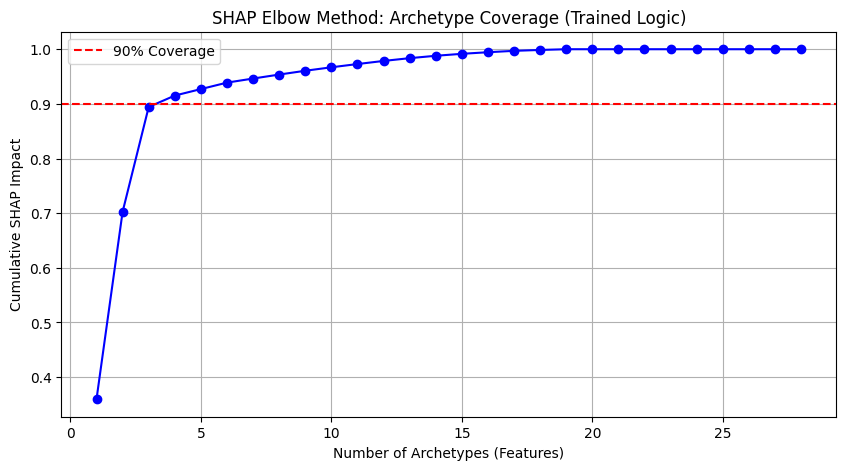

--- SOP ARCHETYPE DEFINITION ---
Criterion A (90% Threshold): 13 features
Criterion B (Elbow Point):    4 features
Final Strict Selection (k):  13
--------------------------------
--- SOP ARCHETYPE DEFINITION ---
Method: SHAP Global Importance (Training Set)
Archetypes Selected (k=13):
  5. Days for shipping (real) | Impact Score: 4.6394
  6. Days for shipment (scheduled) | Impact Score: 4.4267
  4. Type_TRANSFER | Impact Score: 2.4762
  12. Order Item Id | Impact Score: 0.2697
  25. ship_hour | Impact Score: 0.1532
  26. order_hour | Impact Score: 0.1527
  24. order_day_of_week | Impact Score: 0.0963
  7. Benefit per order | Impact Score: 0.0939
  23. ship_day_of_week | Impact Score: 0.0900
  8. Sales per customer | Impact Score: 0.0818
  11. Order Item Discount | Impact Score: 0.0766
  14. Order Item Profit Ratio | Impact Score: 0.0735
  27. ship_daypart_n | Impact Score: 0.0655
--------------------------------
✅ Stratified Test Suite Created: 178 records.
✅ Archetypes covered: ['Exe

In [140]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. DYNAMIC METADATA MAPPING (Ingredient Provision) ---
# Finds the correct column names dynamically
#col_map = {c.lower(): c for c in desc_df.columns}
#f_col = col_map.get('fields', col_map.get('field', col_map.get('fieldname', 'Fields')))
#d_col = col_map.get('description', 'Description')
#desc_map = dict(zip(desc_df[f_col], desc_df[d_col]))

# Mapping for decoding categorical values
shipping_map = {0.0: 'Standard Class', 1.0: 'Second Class', 2.0: 'First Class', 3.0: 'Same Day'}
payment_columns = ['Type_CASH', 'Type_DEBIT', 'Type_PAYMENT', 'Type_TRANSFER']

# --- 2. SHAP ALIGNMENT & ELBOW PLOT (Using Training Data) ---
# We use train_global_importances defined in Cell 22
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns, 
    'importance': train_global_importances
}).sort_values(by='importance', ascending=False)

feature_importance_df['cumulative_perc'] = feature_importance_df['importance'].cumsum() / feature_importance_df['importance'].sum()

# Visualization: SHAP Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(feature_importance_df) + 1), feature_importance_df['cumulative_perc'], marker='o', color='b')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Coverage')
# plt.axvline(x=5, color='g', label='Elbow Point (k=5)')
plt.title('SHAP Elbow Method: Archetype Coverage (Trained Logic)')
# ... (rest of the plotting code remains the same) ...
plt.xlabel('Number of Archetypes (Features)')
plt.ylabel('Cumulative SHAP Impact')
plt.legend()
plt.grid(True)
plt.show()

# --- 3. DECODED SUITE GENERATION (The "Suitcase" Logic) ---

# --- 1. DEFINE THRESHOLD AND ELBOW ---
# Criterion A: 90% Explainability Threshold
#threshold_idx = feature_importance_df[feature_importance_df['cumulative_perc'] >= 0.90].index[0]
#k_threshold = threshold_idx + 1 # Convert 0-index to count

#---------------------------------------------------------
# 1. Correctly sort and reset the index so row numbers match current ranking
fixed_df = feature_importance_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

# 2. Find the index that satisfies a high-confidence information ceiling
threshold_idx = fixed_df[fixed_df['cumulative_perc'] >= 0.98].index[0]
k_threshold = threshold_idx + 1
#----------------------------------------------------------

# Criterion B: Elbow Point (Heuristic: where the gain per feature drops below 5%)
# We look for the point where the marginal improvement slows down significantly
marginal_gain = feature_importance_df['importance'] / feature_importance_df['importance'].sum()
elbow_idx = np.where(marginal_gain < 0.05)[0][0] 
k_elbow = elbow_idx + 1

# THE "STRICT" SELECTION (Fulfills BOTH)
K_ARCHETYPES = int(max(k_threshold, k_elbow))

# Update the suite using the dynamic K
top_features_list = feature_importance_df.head(K_ARCHETYPES)['feature'].tolist()

# 2. Group top features by Archetype
grouped_archetypes = defaultdict(list)
for feat in top_features_list:
    arch = feature_to_archetype_map.get(feat, 'General')
    grouped_archetypes[arch].append(feat)

# Ensure 'Others' is handled if you have features not in top_features_list
grouped_archetypes['General'].append('Others')

print(f"--- SOP ARCHETYPE DEFINITION ---")
print(f"Criterion A (90% Threshold): {k_threshold} features")
print(f"Criterion B (Elbow Point):    {k_elbow} features")
print(f"Final Strict Selection (k):  {K_ARCHETYPES}")
print("--------------------------------")

# Extract the features
top_features_df = feature_importance_df.head(K_ARCHETYPES)
top_features_list = top_features_df['feature'].tolist()

# DIAGNOSTIC PRINT: This is the evidence for your thesis
print(f"--- SOP ARCHETYPE DEFINITION ---")
print(f"Method: SHAP Global Importance (Training Set)")
print(f"Archetypes Selected (k={K_ARCHETYPES}):")
for i, row in top_features_df.iterrows():
    print(f"  {i+1}. {row['feature']} | Impact Score: {row['importance']:.4f}")
print("--------------------------------")

curated_test_suite = pd.DataFrame()

# Updated loop to use the variable top_features_list
def get_decoded_samples(feat_name, n_rows):
    if feat_name == 'Others':
        other_indices = [i for i, f in enumerate(feature_names) if f not in top_features_list]
        impacts = np.abs(late_test_shap_values[:, other_indices]).sum(axis=1)
    else:
        impacts = np.abs(late_test_shap_values[:, feature_names.get_loc(feat_name)])
        
    top_pos = np.argsort(impacts)[-n_rows:]
    samples = data.iloc[late_predictions.index[top_pos]].copy()
    
    samples['Primary_Delay_Reason'] = feat_name
    samples['Shipping Mode'] = samples['Shipping Mode'].map(lambda x: shipping_map.get(x, x))
    samples['Payment Type'] = samples['Type']
    
    return samples

# Create the suite
for feat in top_features_list:
    curated_test_suite = pd.concat([curated_test_suite, get_decoded_samples(feat, 30)])

curated_test_suite = pd.concat([curated_test_suite, get_decoded_samples('Others', 30)])

# --- 3. DYNAMIC SUITE GENERATION (Manual/Expert Mapping Mode) ---

# A. Calculate the dynamic K
K_ARCHETYPES = int(max(k_threshold, k_elbow))
top_features_list = feature_importance_df.head(K_ARCHETYPES)['feature'].tolist()

# B. Function: No longer does automatic mapping
def get_decoded_samples(feat_name, n_rows):
    # Determine the index (either specific feature or 'Others')
    if feat_name == 'Others':
        other_indices = [i for i, f in enumerate(feature_names) if f not in top_features_list]
        impacts = np.abs(late_test_shap_values[:, other_indices]).sum(axis=1)
    else:
        impacts = np.abs(late_test_shap_values[:, feature_names.get_loc(feat_name)])
        
    top_pos = np.argsort(impacts)[-n_rows:]
    samples = data.iloc[late_predictions.index[top_pos]].copy()
    
    # Simple assignment: The technical feature name becomes the reason
    # You will map these manually to your SOP categories in your thesis/knowledge base
    samples['Primary_Delay_Reason'] = feat_name
    
    # Apply categorical decoding
    samples['Shipping Mode'] = samples['Shipping Mode'].map(lambda x: shipping_map.get(x, x))
    samples['Payment Type'] = samples['Type']
    
    return samples

# Create the suite
curated_test_suite = pd.DataFrame()

for arch, features in grouped_archetypes.items():
    arch_samples = pd.DataFrame()
    
    # Collect samples for all features within this archetype
    for feat in features:
        arch_samples = pd.concat([arch_samples, get_decoded_samples(feat, 30)])
    
    # Drop duplicates and sample exactly 30 for the archetype
    arch_samples = arch_samples.drop_duplicates()
    if len(arch_samples) > 30:
        arch_samples = arch_samples.sample(n=30, random_state=42)
        
    curated_test_suite = pd.concat([curated_test_suite, arch_samples])

# Final Cleanup & Save
# Remove the helper fields before export to mimic real-world blind input
final_suite = curated_test_suite.drop(columns=['Primary_Delay_Reason']).drop_duplicates()
final_suite = final_suite.sample(frac=1, random_state=42)
final_suite.to_csv("curated_late_delivery_test_suite.csv", index=False)

print(f"✅ Stratified Test Suite Created: {len(final_suite)} records.")
print(f"✅ Archetypes covered: {list(grouped_archetypes.keys())}")

| Category | Fields to Prune | Reason for Pruning |
| :--- | :--- | :--- |
| **Sensitive/Masked** | `Customer Email`, `Customer Password`, `Customer Fname`, `Customer Lname`, `Customer Street` | These are either masked (XXXXXXXXX) or too personal. They provide no value for logistics resolution. |
| **Internal Database IDs** | `Category Id`, `Customer Id`, `Department Id`, `Order Id`, `Product Card Id`, etc. | These are numerical primary keys for SQL databases. LLMs cannot "reason" with an ID number; they need the **Names** instead. |
| **Geospatial Noise** | `Latitude`, `Longitude`, `Customer Zipcode`, `Order Zipcode` | Coordinates and Zipcodes are high-noise. Cities and Countries provide better semantic context for shipping rules. |
| **Web/Status Noise** | `Product Image`, `Product Description`, `Product Status` | URLs and empty descriptions consume tokens without adding logic. `Product Status` (0/1) is less useful than `Order Status`. |
| **Redundant** | `Primary_Delay_Reason` | This is already being sent in the top-level `archetype` field of your JSON payload. |

# SECTION E

In [160]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import requests
import json
import pandas as pd
import time

WEBHOOK_URL = "http://localhost:5680/webhook-test/ml-shap-ingest"
#WEBHOOK_URL = "http://localhost:5680/webhook/ml-shap-ingest"


# --- 1. SETUP UI COMPONENTS ---
# Create Archetype column based on your feature map
curated_test_suite['Archetype'] = curated_test_suite['Primary_Delay_Reason'].map(feature_to_archetype_map).fillna('General')

# Ensure 'Archetype' exists in final_suite from your previous steps
archetype_options = sorted(curated_test_suite['Archetype'].unique().tolist())

archetype_dropdown = widgets.Dropdown(
    options=archetype_options,
    description='Archetype:',
    style={'description_width': 'initial'}
)

feature_dropdown = widgets.Dropdown(
    description='SHAP Driver:',
    style={'description_width': 'initial'}
)

order_id_dropdown = widgets.Dropdown(
    description='Order Item ID:',
    style={'description_width': 'initial'}
)

send_button = widgets.Button(
    description='Send to n8n',
    button_style='success', 
    tooltip='Click to send this payload to n8n',
    icon='paper-plane'
)

output_area = widgets.Output()

# --- 2. HIERARCHICAL UPDATING LOGIC ---
def update_feature_dropdown(*args):
    """Updates SHAP Drivers based on selected Archetype."""
    selected_arch = archetype_dropdown.value
    filtered_df = curated_test_suite[curated_test_suite['Archetype'] == selected_arch]
    feature_dropdown.options = sorted(filtered_df['Primary_Delay_Reason'].unique().tolist())

def update_order_ids(*args):
    """Updates Order IDs based on selected SHAP Driver."""
    selected_feat = feature_dropdown.value
    if not selected_feat: return
    
    filtered_ids = curated_test_suite[curated_test_suite['Primary_Delay_Reason'] == selected_feat]
    order_id_map = data.loc[filtered_ids.index, 'Order Item Id'].to_dict()
    order_id_dropdown.options = [(f"ID: {v} (Idx: {k})", k) for k, v in order_id_map.items()]

# Connect observers
archetype_dropdown.observe(update_feature_dropdown, 'value')
feature_dropdown.observe(update_order_ids, 'value')

# Initialize
update_feature_dropdown()
update_order_ids()

# --- 3. THE SEND FUNCTION (Logic remains identical) ---
# --- 3. THE SEND FUNCTION (UPDATED TO PROCESS MULTIPLE MATCHING RECORDS SEPARATELY) ---
def process_and_send(b):
    with output_area:
        clear_output()
        target_index = order_id_dropdown.value
        
        if target_index is None:
            print("⚠️ Please select an Order Item ID first.")
            return

        # 1. Pull all matching records
        selected_rows = curated_test_suite.loc[[target_index]]

        print(f"🔍 Found {len(selected_rows)} record(s) for index: {target_index}")
        
        # ─── LOOP THROUGH EACH MATCHING RECORD INDIVIDUALLY ───
        for loop_idx, (idx_label, row_suitcase) in enumerate(selected_rows.iterrows()):
            print(f"\n▶️ [Record {loop_idx + 1}/{len(selected_rows)}] Processing Index: {idx_label}")
            
            # ✅ FIXED: Extract ML input row safely using label indexing
            if idx_label in X_test.index:
                ml_input = X_test.loc[[idx_label]]
            else:
                ml_input = X_test.loc[[target_index]].iloc[[0]]
            
            # --- SEMANTIC PRUNING ---
            prune_list = [
                'Customer Email', 'Customer Password', 'Customer Fname', 
                'Customer Lname', 'Customer Street', 'Category Id', 
                'Customer Id', 'Department Id', 'Order Customer Id', 
                'Order Id', 'Order Item Cardprod Id', 'Product Card Id', 
                'Product Category Id', 'Latitude', 'Longitude', 
                'Customer Zipcode', 'Order Zipcode', 'Product Image', 
                'Product Description', 'Product Status', 'Primary_Delay_Reason', 'Archetype'
            ]
            
            suitcase_data = {k: v for k, v in row_suitcase.to_dict().items() if k not in prune_list}
            
            if 'Type' in suitcase_data:
                suitcase_data['Payment Type'] = suitcase_data['Type']
            
            # --- ML LOGIC (SHAP) ---
            row_shap = explainer.shap_values(ml_input)[0]
            causes = []
            for i, feature_name in enumerate(ml_input.columns):
                impact = round(float(row_shap[i]), 3)
                if impact > 0.05:
                    causes.append({
                        "feature": feature_name, 
                        "description": desc_map.get(feature_name, "N/A"), 
                        "impact_score": impact
                    })
            
            causes = sorted(causes, key=lambda x: x['impact_score'], reverse=True)
            
            # --- DYNAMIC INGREDIENT PACKAGING ---
            top_driver = str(row_suitcase['Primary_Delay_Reason'])
            top_desc = desc_map.get(top_driver, "N/A")

            payload = {
                "order_id": int(row_suitcase.get('Order Item Id', 0)),
                "problem_archetype": top_driver,
                "archetype_description": top_desc,
                "order_details": suitcase_data,
                "drivers": causes
            }

            # --- DEBUG: DISPLAY THE PAYLOAD ---
            print(f" Anchoring Driver: {top_driver}")
            print(" DEBUG: OUTGOING PAYLOAD TO n8n:")
            print(json.dumps(payload, indent=4))
            print("-" * 60)

            # --- SEND TO N8N ---
            try:
                response = requests.post(
                    WEBHOOK_URL,
                    headers={"Content-Type": "application/json"},
                    json=payload,
                )
                print(
                    f"✅ n8n Status: {response.status_code} | Response: {response.text}"
                )
            except Exception as e:
                print(f"❌ Error sending record {loop_idx + 1}: {e}")

            # 🛑 Pause 5 seconds between sending records to protect LLM Rate Limits
            if loop_idx < len(selected_rows) - 1:
                print(
                    "⏳ Pausing 5 seconds before sending the next domain record to n8n..."
                )
                time.sleep(5.0)

send_button.on_click(process_and_send)

# --- 4. DISPLAY THE DASHBOARD ---
print("🧪 AGENTIC LOGISTICS TEST HARNESS (HIERARCHICAL MODE)")
display(widgets.VBox([archetype_dropdown, feature_dropdown, order_id_dropdown, send_button, output_area]))

🧪 AGENTIC LOGISTICS TEST HARNESS (HIERARCHICAL MODE)
